Generating BA graph...


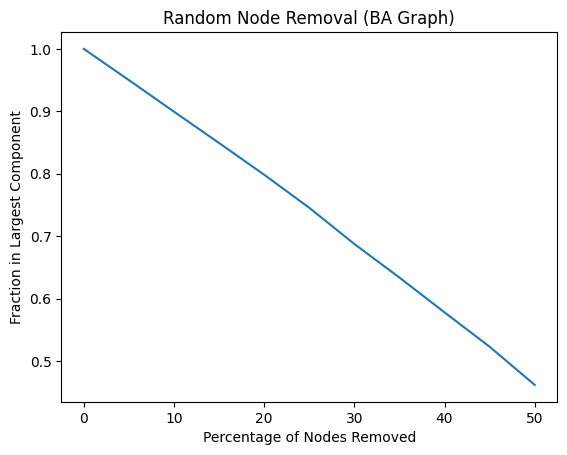

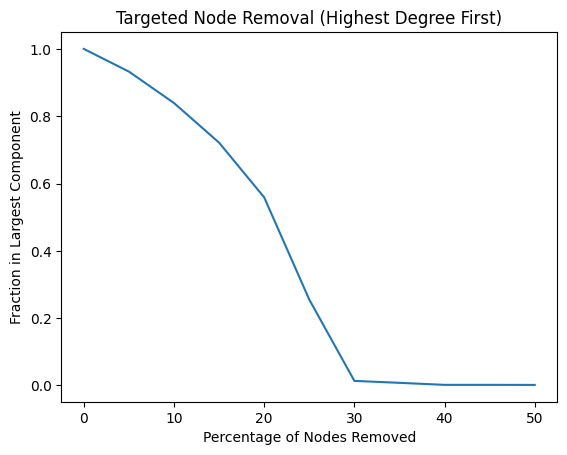

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

n = 5000
m = 3

print("Generating BA graph...")
G_original = nx.barabasi_albert_graph(n, m)

removal_percentages = list(range(0, 55, 5))  # 0% to 50%
random_lcc = []
targeted_lcc = []

for percent in removal_percentages:
    G = G_original.copy()
    nodes_to_remove = int((percent / 100) * n)
    
    remove_nodes = random.sample(list(G.nodes()), nodes_to_remove)
    G.remove_nodes_from(remove_nodes)
    
    if len(G) > 0:
        largest_cc = max(nx.connected_components(G), key=len)
        random_lcc.append(len(largest_cc) / n)
    else:
        random_lcc.append(0)

for percent in removal_percentages:
    G = G_original.copy()
    nodes_to_remove = int((percent / 100) * n)
   
    sorted_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)
    remove_nodes = [node for node, deg in sorted_nodes[:nodes_to_remove]]
    
    G.remove_nodes_from(remove_nodes)
    
    if len(G) > 0:
        largest_cc = max(nx.connected_components(G), key=len)
        targeted_lcc.append(len(largest_cc) / n)
    else:
        targeted_lcc.append(0)

plt.figure()
plt.plot(removal_percentages, random_lcc)
plt.xlabel("Percentage of Nodes Removed")
plt.ylabel("Fraction in Largest Component")
plt.title("Random Node Removal (BA Graph)")
plt.show()

plt.figure()
plt.plot(removal_percentages, targeted_lcc)
plt.xlabel("Percentage of Nodes Removed")
plt.ylabel("Fraction in Largest Component")
plt.title("Targeted Node Removal (Highest Degree First)")
plt.show()
